# Baseline CNN — 対照実験
**目的**: 500枚のラベル付きデータのみを使った通常の教師あり学習の限界を示す。
semi_supervised_mnist.ipynb (SGAN) との比較用。
**設定**:
- 学習データ: ラベル付き 400枚 (train) のみ。無ラベル 3000枚は**使わない**
- 検証:       ラベル付き 100枚 (val)
- テスト:     10000枚 (最後の1回のみ)
- モデル保存: `models/baseline_cnn/`

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.swa_utils import AveragedModel
import torchvision
import torchvision.transforms as T
import numpy as np
import random, os, copy
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cuda


In [2]:
N_LABELED   = 100
N_CLASSES   = 10
IMG_SIZE    = 32
VAL_RATIO   = 0.2
EPOCHS      = 200
LR          = 1e-3
BATCH       = 64          # 小データなので小バッチ
WEIGHT_DECAY= 1e-4

In [3]:
# semi_supervised_mnist.ipynb と同じ分割ロジック (同一 SEED)
tf = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
])
full_train = torchvision.datasets.MNIST("./data", train=True,  download=True, transform=tf)
test_ds    = torchvision.datasets.MNIST("./data", train=False, download=True, transform=tf)

per_class = N_LABELED // N_CLASSES
labeled_idx = []
counts = {c: 0 for c in range(N_CLASSES)}
for i in torch.randperm(len(full_train)).tolist():
    _, lbl = full_train[i]
    if counts[lbl] < per_class:
        labeled_idx.append(i); counts[lbl] += 1
    if len(labeled_idx) == N_LABELED:
        break

def collect(ds, idx):
    imgs, lbls = [], []
    for i in idx:
        im, lb = ds[i]; imgs.append(im); lbls.append(lb)
    return torch.stack(imgs), torch.tensor(lbls)

lx, ly = collect(full_train, labeled_idx)

# Stratified train / val split
val_per = max(1, int(per_class * VAL_RATIO))
train_idx, val_idx, vcounts = [], [], {c: 0 for c in range(N_CLASSES)}
for i in torch.randperm(len(lx)).tolist():
    c = ly[i].item()
    if vcounts[c] < val_per: val_idx.append(i);   vcounts[c] += 1
    else:                    train_idx.append(i)

lx_train, ly_train = lx[train_idx], ly[train_idx]
lx_val,   ly_val   = lx[val_idx],   ly[val_idx]
test_imgs = torch.stack([test_ds[i][0] for i in range(len(test_ds))])
test_lbls = torch.tensor([test_ds[i][1] for i in range(len(test_ds))])

print(f"Labeled train: {len(lx_train)},  val: {len(lx_val)},  test: {len(test_imgs)}")
print("(Unlabeled 3000枚は使用しない — 通常の教師あり学習)")

Labeled train: 80,  val: 20,  test: 10000
(Unlabeled 3000枚は使用しない — 通常の教師あり学習)


In [4]:
_train_tf = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
])
def augment(x: torch.Tensor) -> torch.Tensor:
    return torch.stack([_train_tf(xi) for xi in x.cpu()])

In [5]:
class SimpleCNN(nn.Module):
    """
    3ブロック CNN。
    MNIST 500枚での限界を示すための標準的な構成。
    """
    def __init__(self, n_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.Conv2d(32, 32, 3, 1, 1), nn.BatchNorm2d(32), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(32, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.AdaptiveAvgPool2d(4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(True), nn.Dropout(0.5),
            nn.Linear(256, n_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

model = SimpleCNN(N_CLASSES).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"SimpleCNN params: {n_params:,}")

SimpleCNN params: 667,178


In [6]:
train_loader = DataLoader(TensorDataset(lx_train, ly_train),
                          batch_size=BATCH, shuffle=True, drop_last=True)
opt   = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, EPOCHS)
ce    = nn.CrossEntropyLoss()

os.makedirs("models/baseline_cnn", exist_ok=True)
save_path  = "models/baseline_cnn/cnn_best.pth"
best_val_acc = 0.0
history = []   # (epoch, train_loss, val_loss, train_acc, val_acc)

@torch.no_grad()
def evaluate(model, imgs, lbls, batch=256):
    ce_eval = nn.CrossEntropyLoss()
    model.eval()
    all_logits, all_preds = [], []
    for i in range(0, len(imgs), batch):
        lg = model(imgs[i:i+batch].to(DEVICE))
        all_logits.append(lg.cpu()); all_preds.append(lg.argmax(1).cpu())
    logits = torch.cat(all_logits); preds = torch.cat(all_preds)
    loss = ce_eval(logits, lbls).item()
    acc  = (preds == lbls).float().mean().item()
    model.train()
    return loss, acc

ep_bar = tqdm(range(EPOCHS), desc="[CNN]", unit="ep")
for epoch in ep_bar:
    model.train(); tot_loss = 0.

    for x, y in train_loader:
        x = augment(x).to(DEVICE); y = y.to(DEVICE)
        logits = model(x)
        loss   = ce(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        tot_loss += loss.item()

    sched.step()
    avg_train_loss = tot_loss / len(train_loader)

    if (epoch + 1) % 10 == 0:
        tr_loss, tr_acc = evaluate(model, lx_train, ly_train)
        vl_loss, vl_acc = evaluate(model, lx_val,   ly_val)
        ep_bar.set_postfix(val_acc=f"{vl_acc*100:.1f}%")
        tqdm.write(
            f"[CNN ep {epoch+1:03d}/{EPOCHS}] "
            f"train_loss={tr_loss:.4f}  val_loss={vl_loss:.4f} | "
            f"train_acc={tr_acc*100:.1f}%  val_acc={vl_acc*100:.1f}%")
        history.append((epoch+1, tr_loss, vl_loss, tr_acc, vl_acc))
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), save_path)
            tqdm.write(f"  => [Best] val_acc={best_val_acc*100:.2f}%  saved.")

model.load_state_dict(torch.load(save_path, map_location=DEVICE, weights_only=True))
print(f"Best val acc: {best_val_acc*100:.2f}%")

[CNN]:   0%|          | 0/200 [00:00<?, ?ep/s]

[CNN ep 010/200] train_loss=2.5577  val_loss=2.5530 | train_acc=10.0%  val_acc=10.0%
  => [Best] val_acc=10.00%  saved.
[CNN ep 020/200] train_loss=4.1611  val_loss=4.0739 | train_acc=10.0%  val_acc=10.0%
[CNN ep 030/200] train_loss=2.4067  val_loss=2.1622 | train_acc=18.8%  val_acc=20.0%
  => [Best] val_acc=20.00%  saved.
[CNN ep 040/200] train_loss=0.9749  val_loss=1.1334 | train_acc=72.5%  val_acc=60.0%
  => [Best] val_acc=60.00%  saved.
[CNN ep 050/200] train_loss=0.6829  val_loss=0.9612 | train_acc=82.5%  val_acc=65.0%
  => [Best] val_acc=65.00%  saved.
[CNN ep 060/200] train_loss=0.4691  val_loss=0.8127 | train_acc=93.8%  val_acc=70.0%
  => [Best] val_acc=70.00%  saved.
[CNN ep 070/200] train_loss=0.3487  val_loss=0.9280 | train_acc=93.8%  val_acc=65.0%
[CNN ep 080/200] train_loss=0.2587  val_loss=0.8257 | train_acc=93.8%  val_acc=70.0%
[CNN ep 090/200] train_loss=0.1976  val_loss=0.8456 | train_acc=95.0%  val_acc=70.0%
[CNN ep 100/200] train_loss=0.1940  val_loss=0.7519 | train_

In [7]:
@torch.no_grad()
def test_evaluate(model, test_imgs, test_lbls, batch=256, label=""):
    preds = []
    for i in tqdm(range(0, len(test_imgs), batch), desc=f"Test [{label}]", leave=False):
        logits = model(test_imgs[i:i+batch].to(DEVICE))
        preds.append(logits.argmax(1).cpu())
    preds = torch.cat(preds)
    acc   = (preds == test_lbls).float().mean().item()
    print(f"[{label}] ★ TEST Accuracy: {acc*100:.2f}%")
    return acc

print("\n=== Final Test Evaluation (1回のみ) ===")
cnn_test_acc = test_evaluate(model, test_imgs, test_lbls, label="SimpleCNN")


=== Final Test Evaluation (1回のみ) ===


Test [SimpleCNN]:   0%|          | 0/40 [00:00<?, ?it/s]

[SimpleCNN] ★ TEST Accuracy: 75.14%


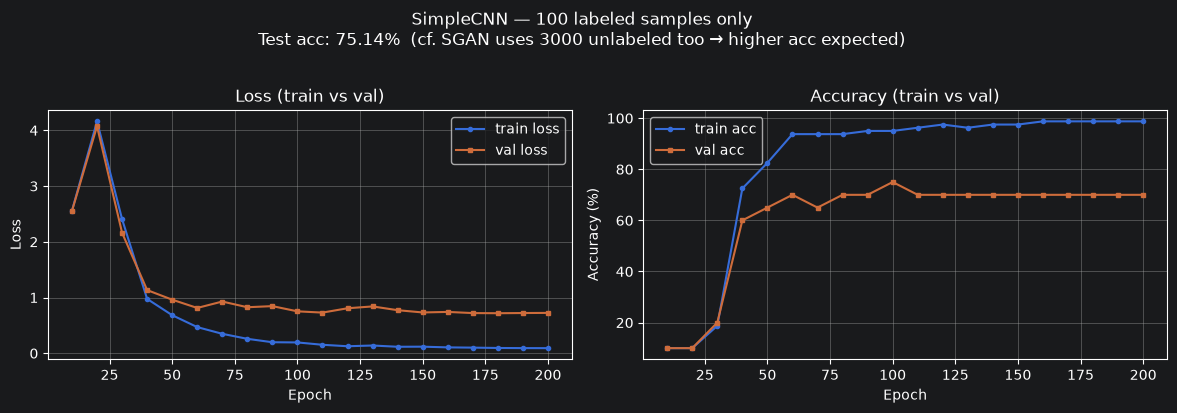

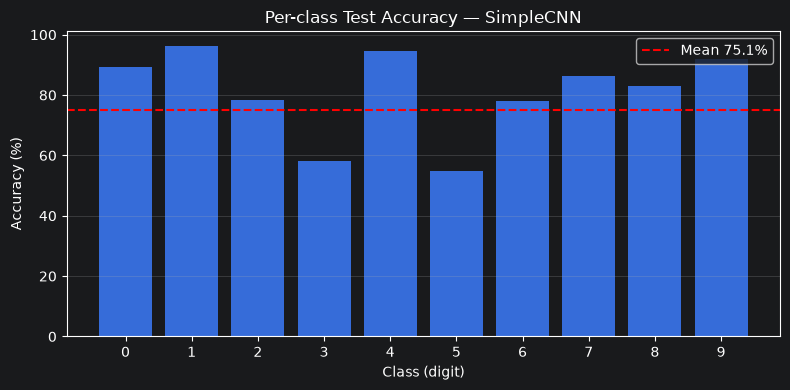


=== Per-class accuracy ===
  Digit 0: 89.4%
  Digit 1: 96.3%
  Digit 2: 78.2%
  Digit 3: 58.0%
  Digit 4: 94.7%
  Digit 5: 54.7%
  Digit 6: 78.2%
  Digit 7: 86.5%
  Digit 8: 83.0%
  Digit 9: 92.1%

SimpleCNN (500 labeled, NO unlabeled): 75.14%
SGAN (semi-supervised) との比較:
  → モデル/val accuracy は semi_supervised_mnist.ipynb を参照


In [8]:
try:
    import matplotlib.pyplot as plt

    eps       = [h[0] for h in history]
    tr_losses = [h[1] for h in history]
    vl_losses = [h[2] for h in history]
    tr_accs   = [h[3]*100 for h in history]
    vl_accs   = [h[4]*100 for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(eps, tr_losses, "o-", ms=3, label="train loss")
    axes[0].plot(eps, vl_losses, "s-", ms=3, label="val loss")
    axes[0].set(xlabel="Epoch", ylabel="Loss", title="Loss (train vs val)")
    axes[0].legend(); axes[0].grid(0.3)

    axes[1].plot(eps, tr_accs, "o-", ms=3, label="train acc")
    axes[1].plot(eps, vl_accs, "s-", ms=3, label="val acc")
    axes[1].set(xlabel="Epoch", ylabel="Accuracy (%)",
                title="Accuracy (train vs val)")
    axes[1].legend(); axes[1].grid(0.3)

    plt.suptitle(
        f"SimpleCNN — {N_LABELED} labeled samples only\n"
        f"Test acc: {cnn_test_acc*100:.2f}%  "
        f"(cf. SGAN uses 3000 unlabeled too → higher acc expected)",
        y=1.02)
    plt.tight_layout(); plt.show()

    # Per-class accuracy
    model.eval()
    with torch.no_grad():
        all_preds = []
        for i in range(0, len(test_imgs), 256):
            all_preds.append(model(test_imgs[i:i+256].to(DEVICE)).argmax(1).cpu())
        all_preds = torch.cat(all_preds)
    per_class_acc = [(all_preds[test_lbls==c] == c).float().mean().item()*100
                     for c in range(N_CLASSES)]
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(range(N_CLASSES), per_class_acc)
    ax.set(xlabel="Class (digit)", ylabel="Accuracy (%)",
           title="Per-class Test Accuracy — SimpleCNN")
    ax.set_xticks(range(N_CLASSES))
    ax.axhline(cnn_test_acc*100, color='r', linestyle='--', label=f"Mean {cnn_test_acc*100:.1f}%")
    ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    print("\n=== Per-class accuracy ===")
    for c, acc in enumerate(per_class_acc):
        print(f"  Digit {c}: {acc:.1f}%")

except ImportError:
    pass

print(f"\n{'='*50}")
print(f"SimpleCNN (500 labeled, NO unlabeled): {cnn_test_acc*100:.2f}%")
print(f"{'='*50}")
print("SGAN (semi-supervised) との比較:")
print("  → モデル/val accuracy は semi_supervised_mnist.ipynb を参照")